In [1]:
import pandas as pd
import random as rd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

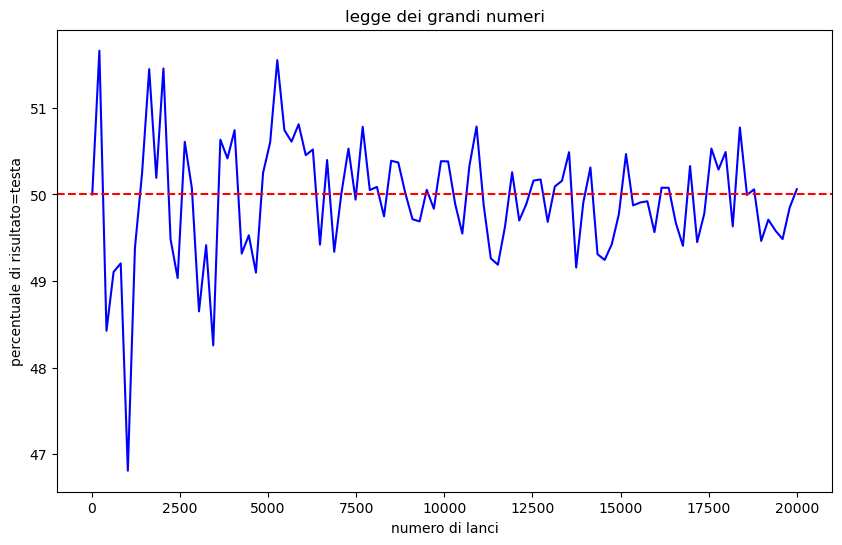

In [ ]:
#esercizio 1
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=np.linspace(10,20000,100)
# campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(int(n)) for n in campioni] 
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

'''
oppure:
plt.plot(campioni, risultati_campioni)
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
'''



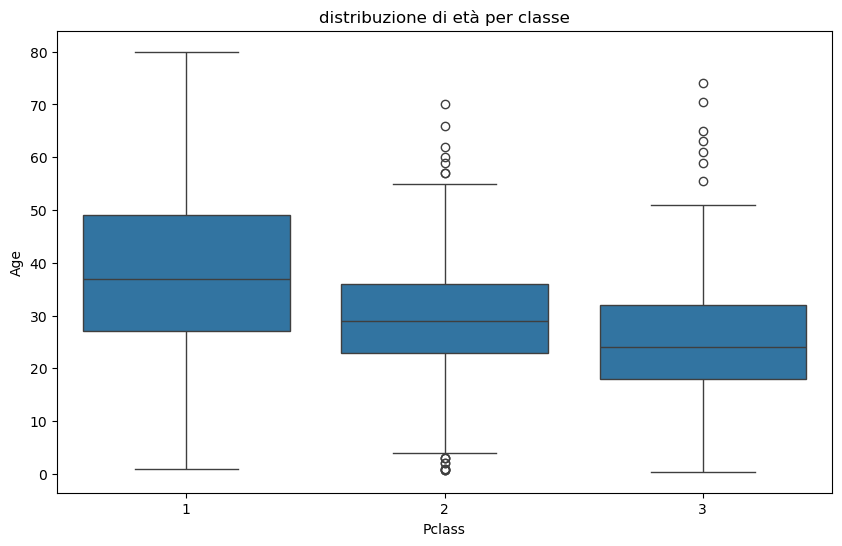

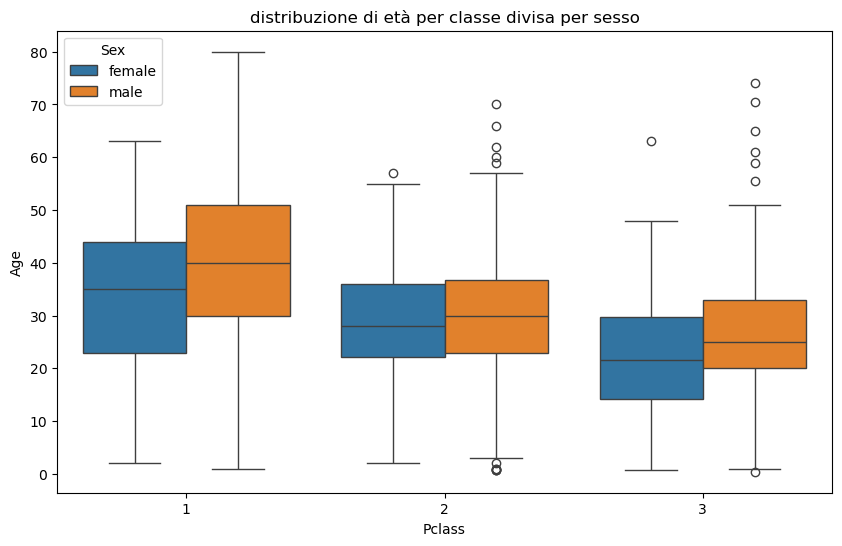

In [ ]:
#esercizio 2
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

dimesione_df=[df.shape[0],df.shape[1]]
valori_mancanti=df.isnull().sum()
df["Embarked"].fillna(df["Embarked"].mode()[0])
righe_duplicate=df.duplicated().sum()
df["Age"].fillna(df["Age"].mean()[0])
età_media_passeggeri_per_classe=df.groupby("Pclass")["Age"].mean()

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Pclass",y="Age")
plt.title("distribuzione di età per classe")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Pclass",y="Age",hue="Sex")
plt.title("distribuzione di età per classe divisa per sesso")
plt.show()

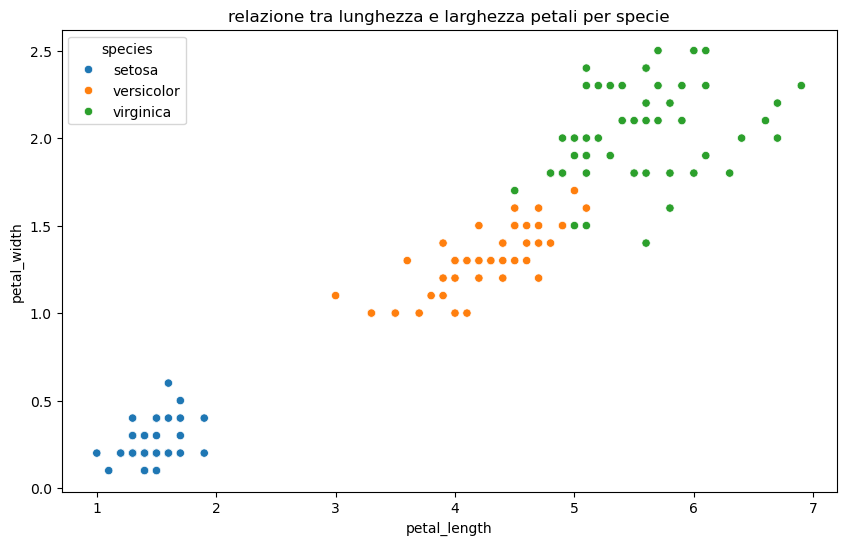

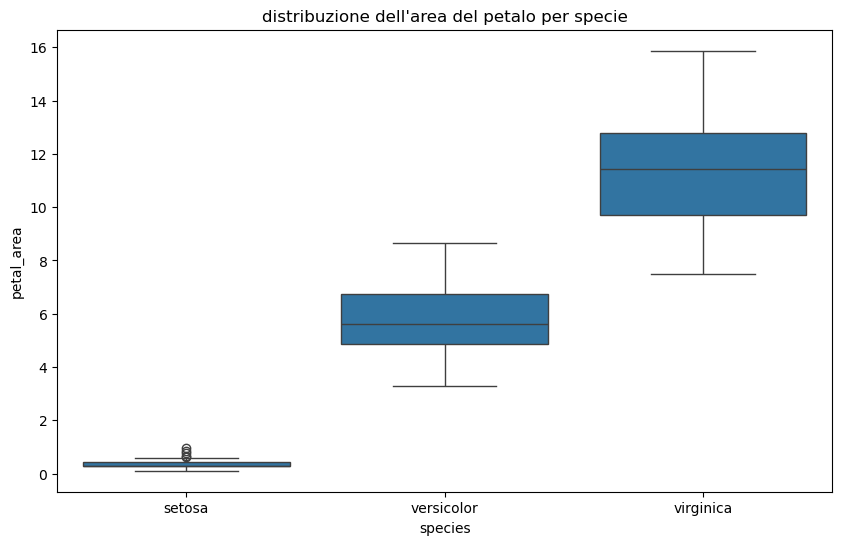

In [4]:
#esercizio 3
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

num_specie=len(df["species"].unique())   #oppure df["species"].value_counts()
lunghezza_media_petalo_per_specie=df.groupby("species")["petal_length"].mean()
larghezza_media_petalo_per_specie=df.groupby("species")["petal_width"].mean()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("relazione tra lunghezza e larghezza petali per specie")
plt.show() 

df["petal_area"] = df["petal_length"] * df["petal_width"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="species", y="petal_area")
plt.title("distribuzione dell'area del petalo per specie")
plt.show()